This is a short introduction into pytorch. The goal for you is to be able to create your own neural networks with torch. As in the last exercise, this ANN will not have a hidden layer.

For the following code, you do not need to do anything. However, you should understand what we are doing, since you have to redo these things in the next exercises.

If you need any help, you can find lots of useful information on the pytorch website:
https://pytorch.org/docs/stable/index.html

A good introduction can also be found here:
https://pytorch.org/tutorials/beginner/pytorch_with_examples.html

# Import Libraries

In [2]:
import torch
import torch.nn.functional as F
import torch.nn            as nn
import torch.optim         as optim

import numpy as np
import math
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

%matplotlib inline

# Create Data

In the Toy example, we have a two-dimensional data set: $(x_1,x_2) \in [-1,1] \times [-1,1]$. We want to train the network to output 1, if $x_1 + x_2 >= 1$. Otherwise, the network should output 0. Therefore, we are going to create a dataset with the corresponding labels. We furthermore divide the data into a training set and a test set.

In [4]:
# Define total number of samples
tot_number_samples = 10000

# Create a dataset randomly and calculate the necessary labels
X = np.random.uniform(-1,1,size=(tot_number_samples,2))
y = (X[:,0] + X[:,1] + np.random.randn(tot_number_samples)/3 >= 1)*1.

# Divide the dataset into a train and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25) #25 % of data is in test set

#if you are unsure with train_test_split does, execute the next line
#help(train_test_split)

In [5]:
# Move data to device
X_train = torch.from_numpy(X_train).float()
y_train = torch.from_numpy(y_train).float()
X_test  = torch.from_numpy(X_test).float()
y_test  = torch.from_numpy(y_test).float()

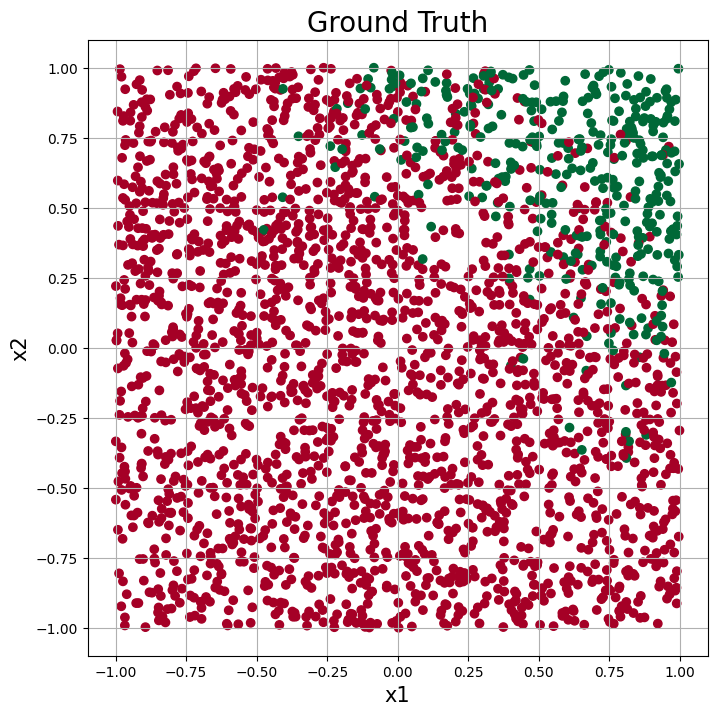

In [6]:
# Plot the test data in a graph for visualization
plt.figure(figsize=(8,8))
plt.scatter(X_test[:,0],X_test[:,1],c=y_test,cmap="RdYlGn")
plt.grid(True)
plt.xlabel('x1',fontsize=15)
plt.ylabel('x2',fontsize=15)
plt.title('Ground Truth',fontsize=20)
plt.show()

# Build the Network

In [7]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()
        
        # Create a single fully connected layer. If you need more than one layer in the future, you need to define them here
        self.dense = nn.Linear(2,1)      # 2 inputs, 1 output
        
    def forward(self,x):
        # This functions tells torch, how the layers are actually connected. More complex networks will have more complex code here
        
        x = torch.sigmoid(self.dense(x)) # This is the layer we defined in __init__
        x = x[:,0]
        
        return x
    
    def predict(self,x):
        # Make a prediction (0 or 1), to which class the data belongs to
        
        out = self.forward(x)
        out = (out>0.5).float()
        return out

In [8]:
ann       = ANN()                                # Make an object of your ANN class
optimizer = optim.Adam(params=ann.parameters())  # Define the optimizer

# Train the Network

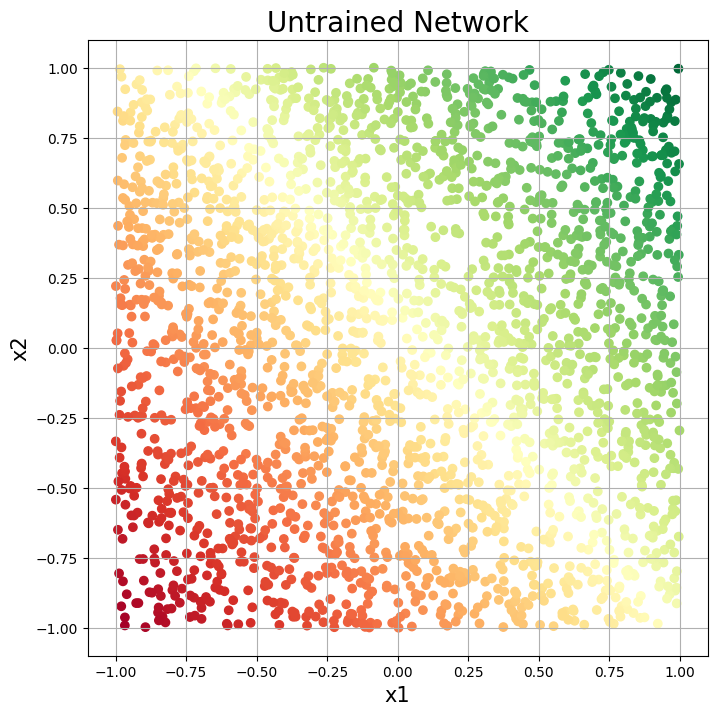

In [9]:
# Make a prediction by the untrained network and plot it
ann.eval()
y_pred = ann.forward(X_test).detach().numpy()

# Plot the raw data
plt.figure(figsize=(8,8))
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred,cmap="RdYlGn")
plt.grid(True)
plt.xlabel('x1',fontsize=15)
plt.ylabel('x2',fontsize=15)
plt.title('Untrained Network',fontsize=20)
plt.show()

In [11]:
n_epochs                = 100
batch_size              = 128

n_iterations_per_epoch  = y_train.shape[0] // batch_size
n_iterations_validation = y_test.shape[0] // batch_size
best_loss_val           = np.inf

for epoch in range(n_epochs):
    ann.train()
    for iteration in range(n_iterations_per_epoch):
        X_batch = X_train[iteration*batch_size:(iteration+1)*batch_size,:]
        y_batch = y_train[iteration*batch_size:(iteration+1)*batch_size]
        
        optimizer.zero_grad()                # Reset the gradients
        
        y_pred  = ann.forward(X_batch)       # make a prediciton
        loss    = F.mse_loss(y_batch,y_pred) # Get the actual loss
        loss.backward()                      # Calculate the gradients.
        
        optimizer.step()                     # Apply the gradients
            
    # Evaluation
    ann.eval()
    y_pred   = ann.predict(X_test)
    loss_val = F.mse_loss(y_test,ann.forward(X_test)).detach().numpy()
    
    accuracy = (torch.mean((torch.abs(y_pred-y_test)<1e-4).float())).detach().numpy()
    
    print("\rEpoch: {}  Val accuracy: {:.4f}%  Loss: {:.6f}{}".format(
        epoch+1, accuracy * 100, loss_val,
        " (improved)" if loss_val < best_loss_val else ""))

    # Update best val loss, if improved
    if loss_val < best_loss_val:
        best_loss_val = loss_val

Epoch: 1  Val accuracy: 79.4800%  Loss: 0.175578 (improved)
Epoch: 2  Val accuracy: 81.8400%  Loss: 0.167147 (improved)
Epoch: 3  Val accuracy: 83.6000%  Loss: 0.159479 (improved)
Epoch: 4  Val accuracy: 85.7200%  Loss: 0.152484 (improved)
Epoch: 5  Val accuracy: 87.1600%  Loss: 0.146088 (improved)
Epoch: 6  Val accuracy: 88.2000%  Loss: 0.140229 (improved)
Epoch: 7  Val accuracy: 89.2800%  Loss: 0.134856 (improved)
Epoch: 8  Val accuracy: 90.1200%  Loss: 0.129922 (improved)
Epoch: 9  Val accuracy: 90.8800%  Loss: 0.125388 (improved)
Epoch: 10  Val accuracy: 91.1200%  Loss: 0.121217 (improved)
Epoch: 11  Val accuracy: 91.6400%  Loss: 0.117377 (improved)
Epoch: 12  Val accuracy: 92.1600%  Loss: 0.113839 (improved)
Epoch: 13  Val accuracy: 92.5600%  Loss: 0.110576 (improved)
Epoch: 14  Val accuracy: 93.0000%  Loss: 0.107563 (improved)
Epoch: 15  Val accuracy: 93.1600%  Loss: 0.104778 (improved)
Epoch: 16  Val accuracy: 92.8800%  Loss: 0.102200 (improved)
Epoch: 17  Val accuracy: 92.9600%

If everything works correctly, the Loss function should be smaller than 0.1.

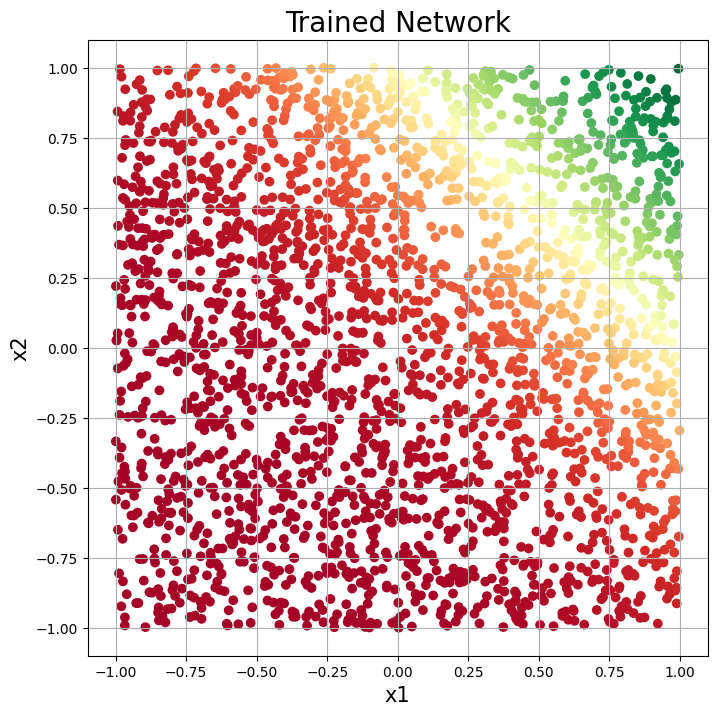

In [12]:
# Make a prediction of the trained network and plot it
ann.eval()
y_pred = ann.forward(X_test).cpu().detach().numpy()

# Plot the raw data
plt.figure(figsize=(8,8))
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred,cmap="RdYlGn")
plt.grid(True)
plt.xlabel('x1',fontsize=15)
plt.ylabel('x2',fontsize=15)
plt.title('Trained Network',fontsize=20)
plt.show()